# 🌳 한눈에 정리하는 머신러닝 기초: 의사결정나무 & 앙상블 기법 완전 정복

이번 복습 노트에서는 복잡한 머신러닝 모델의 동작 원리를 직관적이고 시각적으로 이해하기 쉽게 해주는 **의사결정나무(Decision Tree)**,

이 단일 모델의 한계를 극복하고 예측 성능을 극대화하는 **앙상블(Ensemble) 기법**에 대해 다룹니다.

---

## 📌 의사결정나무 (Decision Tree)의 핵심 특징

의사결정나무는 스무고개 놀이처럼 데이터를 특정 기준에 따라 계속 질문을 던지며 가지를 쳐 나가는 알고리즘입니다.

* **직관성과 해석 용이성**: 복잡한 기존 머신러닝 모델과 달리 예측 과정을 시각적으로 쉽게 이해하고 설명할 수 있습니다.
* **비선형 관계 모델링**: 직선이나 평면으로 나누기 힘든 데이터 패턴도 계단식 경계를 만들어 비선형 관계를 유연하게 표현할 수 있습니다.
* **회귀 & 분류 모두 적용 가능**: 타겟 변수가 연속형(회귀)이든 범주형(분류)이든 상관없이 똑같은 나무 구조로 해결 가능합니다.
* **전처리 최소화**: 데이터의 스케일링(Scaling)이나 정규화 영향이 적어 데이터 전처리에 비교적 덜 민감합니다.
  * **⚠️ 주의점 (과적합)**: 나무가 제한 없이 너무 깊어지면(Tree Depth가 깊어짐) 학습 데이터의 사소한 노이즈까지 다 외워버려 **과적합(Overfitting)** 이 발생하기 매우 쉬움.

---

## 1. 의사결정나무 - 회귀 (Regression)

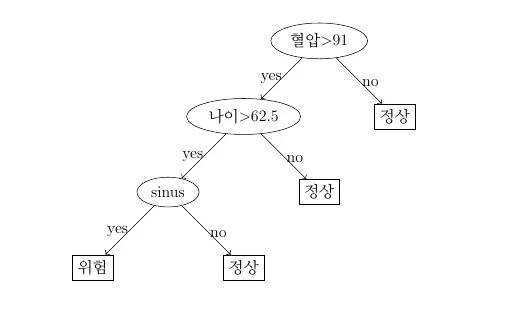

회귀나무의 목표는 **'데이터들을 어떤 기준(구역)으로 어떻게 나눌 것인가?'** 입니다.

* **어떤 구역으로 나눌 것인가? -> RSS (Residual Sum of Squares)**
  * 분할된 영역에 속한 데이터들의 **실제값과 예측값(해당 영역 데이터의 평균값)의 오차 제곱합(RSS)** 을 최소화하는 구역을 선택.

* **어떻게 나눌 것인가? -> 탐욕적 접근법 (Greedy Approach)**
  * 위에서부터 아래로 내려오는 상향식(Top-down) 방식.
  * 매 순간 분할하는 시점마다 가능한 모든 분할 기준을试해보고, 분할 후 RSS 손실이 가장 적어지는 최선의 선택(Greedy)을 반복.

In [ ]:
from sklearn.datasets import make_regression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split

# 1. 회귀용 데이터 생성 및 분할
X_reg, y_reg = make_regression(n_samples=100, n_features=1, noise=15, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# 2. 회귀 의사결정나무 모델 생성 (과적합 방지를 위해 max_depth 설정)
reg = DecisionTreeRegressor(max_depth=5, random_state=100)

# 3. 모델 학습
reg.fit(X_train, y_train)

# 4. 예측값 반환
y_pred_reg = reg.predict(X_test)
print("회귀 의사결정나무 예측 결과 (상위 5개):", y_pred_reg[:5])

---

## 2. 의사결정나무 - 분류 (Classification)

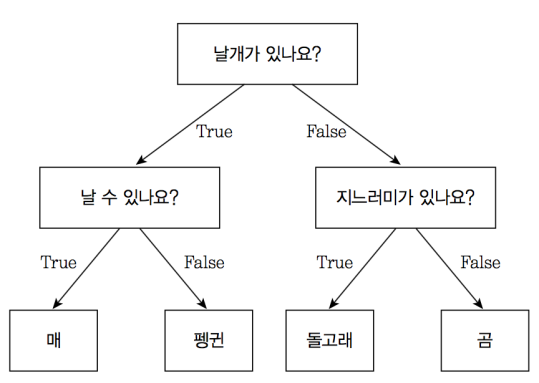

분류 문제에서는 예측값이 숫자의 평균이 아니기 때문에 회귀용 평가 기준인 **RSS를 그대로 쓸 수 없습니다**.


대신 **구역 내 데이터의 '불순도(Impurity)'를 최소화하는 방향**으로 나눕니다.

* **불순도 (Impurity)**:
  * 해당 노드 안에 서로 다른 클래스의 데이터가 얼마나 섞여 있는지를 나타내는 척도.
  * **불순도가 낮다 = 노드가 순수(Pure)하다**: 대부분의 데이터가 동일한 범주(클래스)로만 깔끔하게 이루어져 있음을 뜻 함.
  * 대표적인 지표로 **지니 불순도(Gini)**, **엔트로피(Entropy)** 등이 있음.

In [ ]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

# 1. 분류용 데이터 로드 및 분할
iris = load_iris()
X_cls, y_cls = iris.data, iris.target
X_tr, X_te, y_tr, y_te = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)

# 2. 분류 의사결정나무 모델 생성
# criterion 종류: 'gini' (기본값), 'entropy', 'log_loss'
clf = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=100)

# 3. 모델 학습
clf.fit(X_tr, y_tr)

# 4. 예측값 반환
y_pred_cls = clf.predict(X_te)
print("분류 의사결정나무 예측 결과 (상위 5개):", y_pred_cls[:5])

---

## 3. 앙상블 기법 (Ensemble Learning)

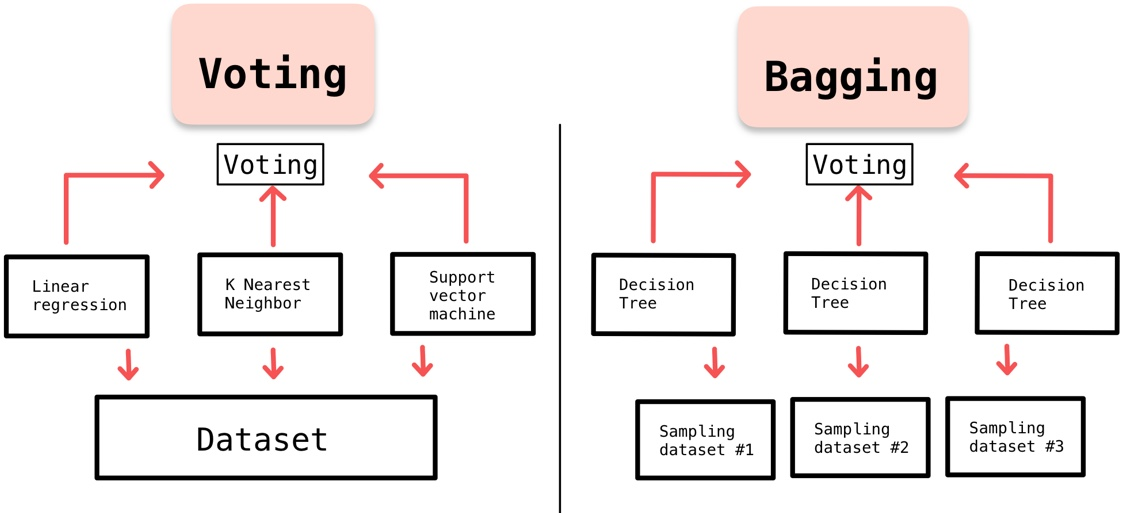

단일 의사결정나무 모델의 과적합 방지 및 예측 성능 극대화를 위해 **여러 개의 모델을 조합하여 활용하는 기법**입니다.

특히 데이터가 복잡하거나 노이즈가 많을 때 강력합니다.

### 3-1. Voting (보팅)

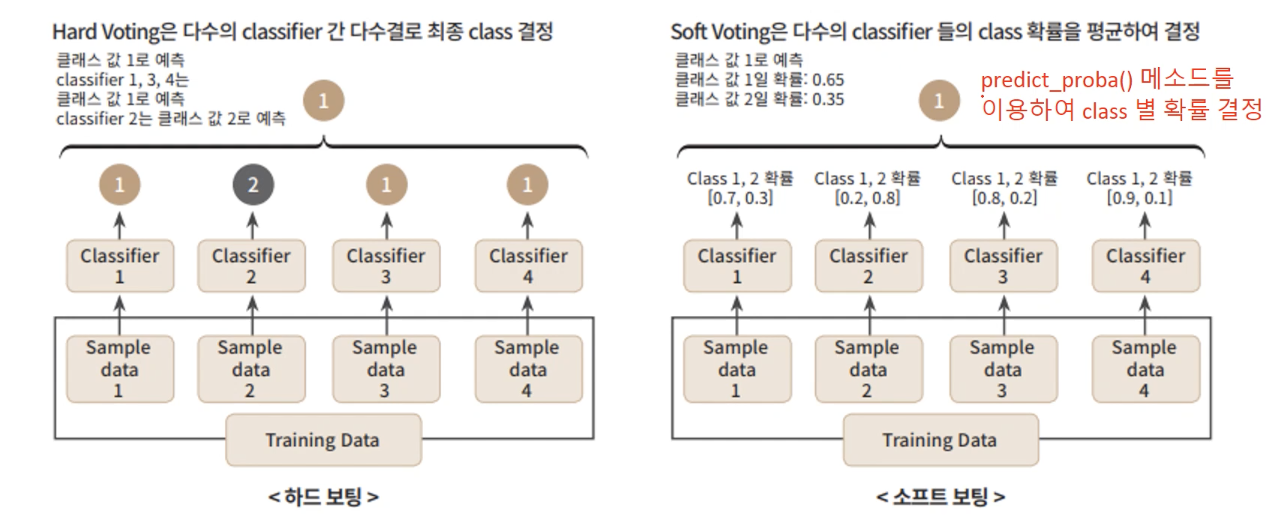

* **개념**: 여러 서로 다른 알고리즘 모델들의 예측 결과를 종합하여 투표로 최종 결과를 결정.
* **방식**:
  * **회귀**: 각 모델 예측값의 **평균**을 취함
  * **분류**:
    * **하드 보팅 (Hard Voting / 직접투표)**: 각 모델의 최다 표를 받은 클래스 선택
    * **소프트 보팅 (Soft Voting / 간접투표)**: 각 모델이 출력한 클래스별 확률의 평균을 구해 가장 높은 확률의 클래스 선택 (보통 성능이 더 우수함)
* **장점**: 직관적이고 연산이 단순하며, 서로 전혀 다른 알고리즘 모델(예: 로지스틱 회귀 + KNN)을 묶을 수 있음.

In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# 서로 다른 개별 알고리즘 모델 객체 생성
lr_clf = LogisticRegression(max_iter=1000)
knn_clf = KNeighborsClassifier(n_neighbors=5)

# VotingClassifier 생성 (voting = 'soft' 또는 'hard')
vo_clf = VotingClassifier(estimators=[('LR', lr_clf), ('KNN', knn_clf)], voting='soft')

# 모델 학습 및 예측
vo_clf.fit(X_tr, y_tr)
y_pred_vo = vo_clf.predict(X_te)
print("Voting 예측 결과 (상위 5개):", y_pred_vo[:5])

### 3-2. Bagging (배깅)

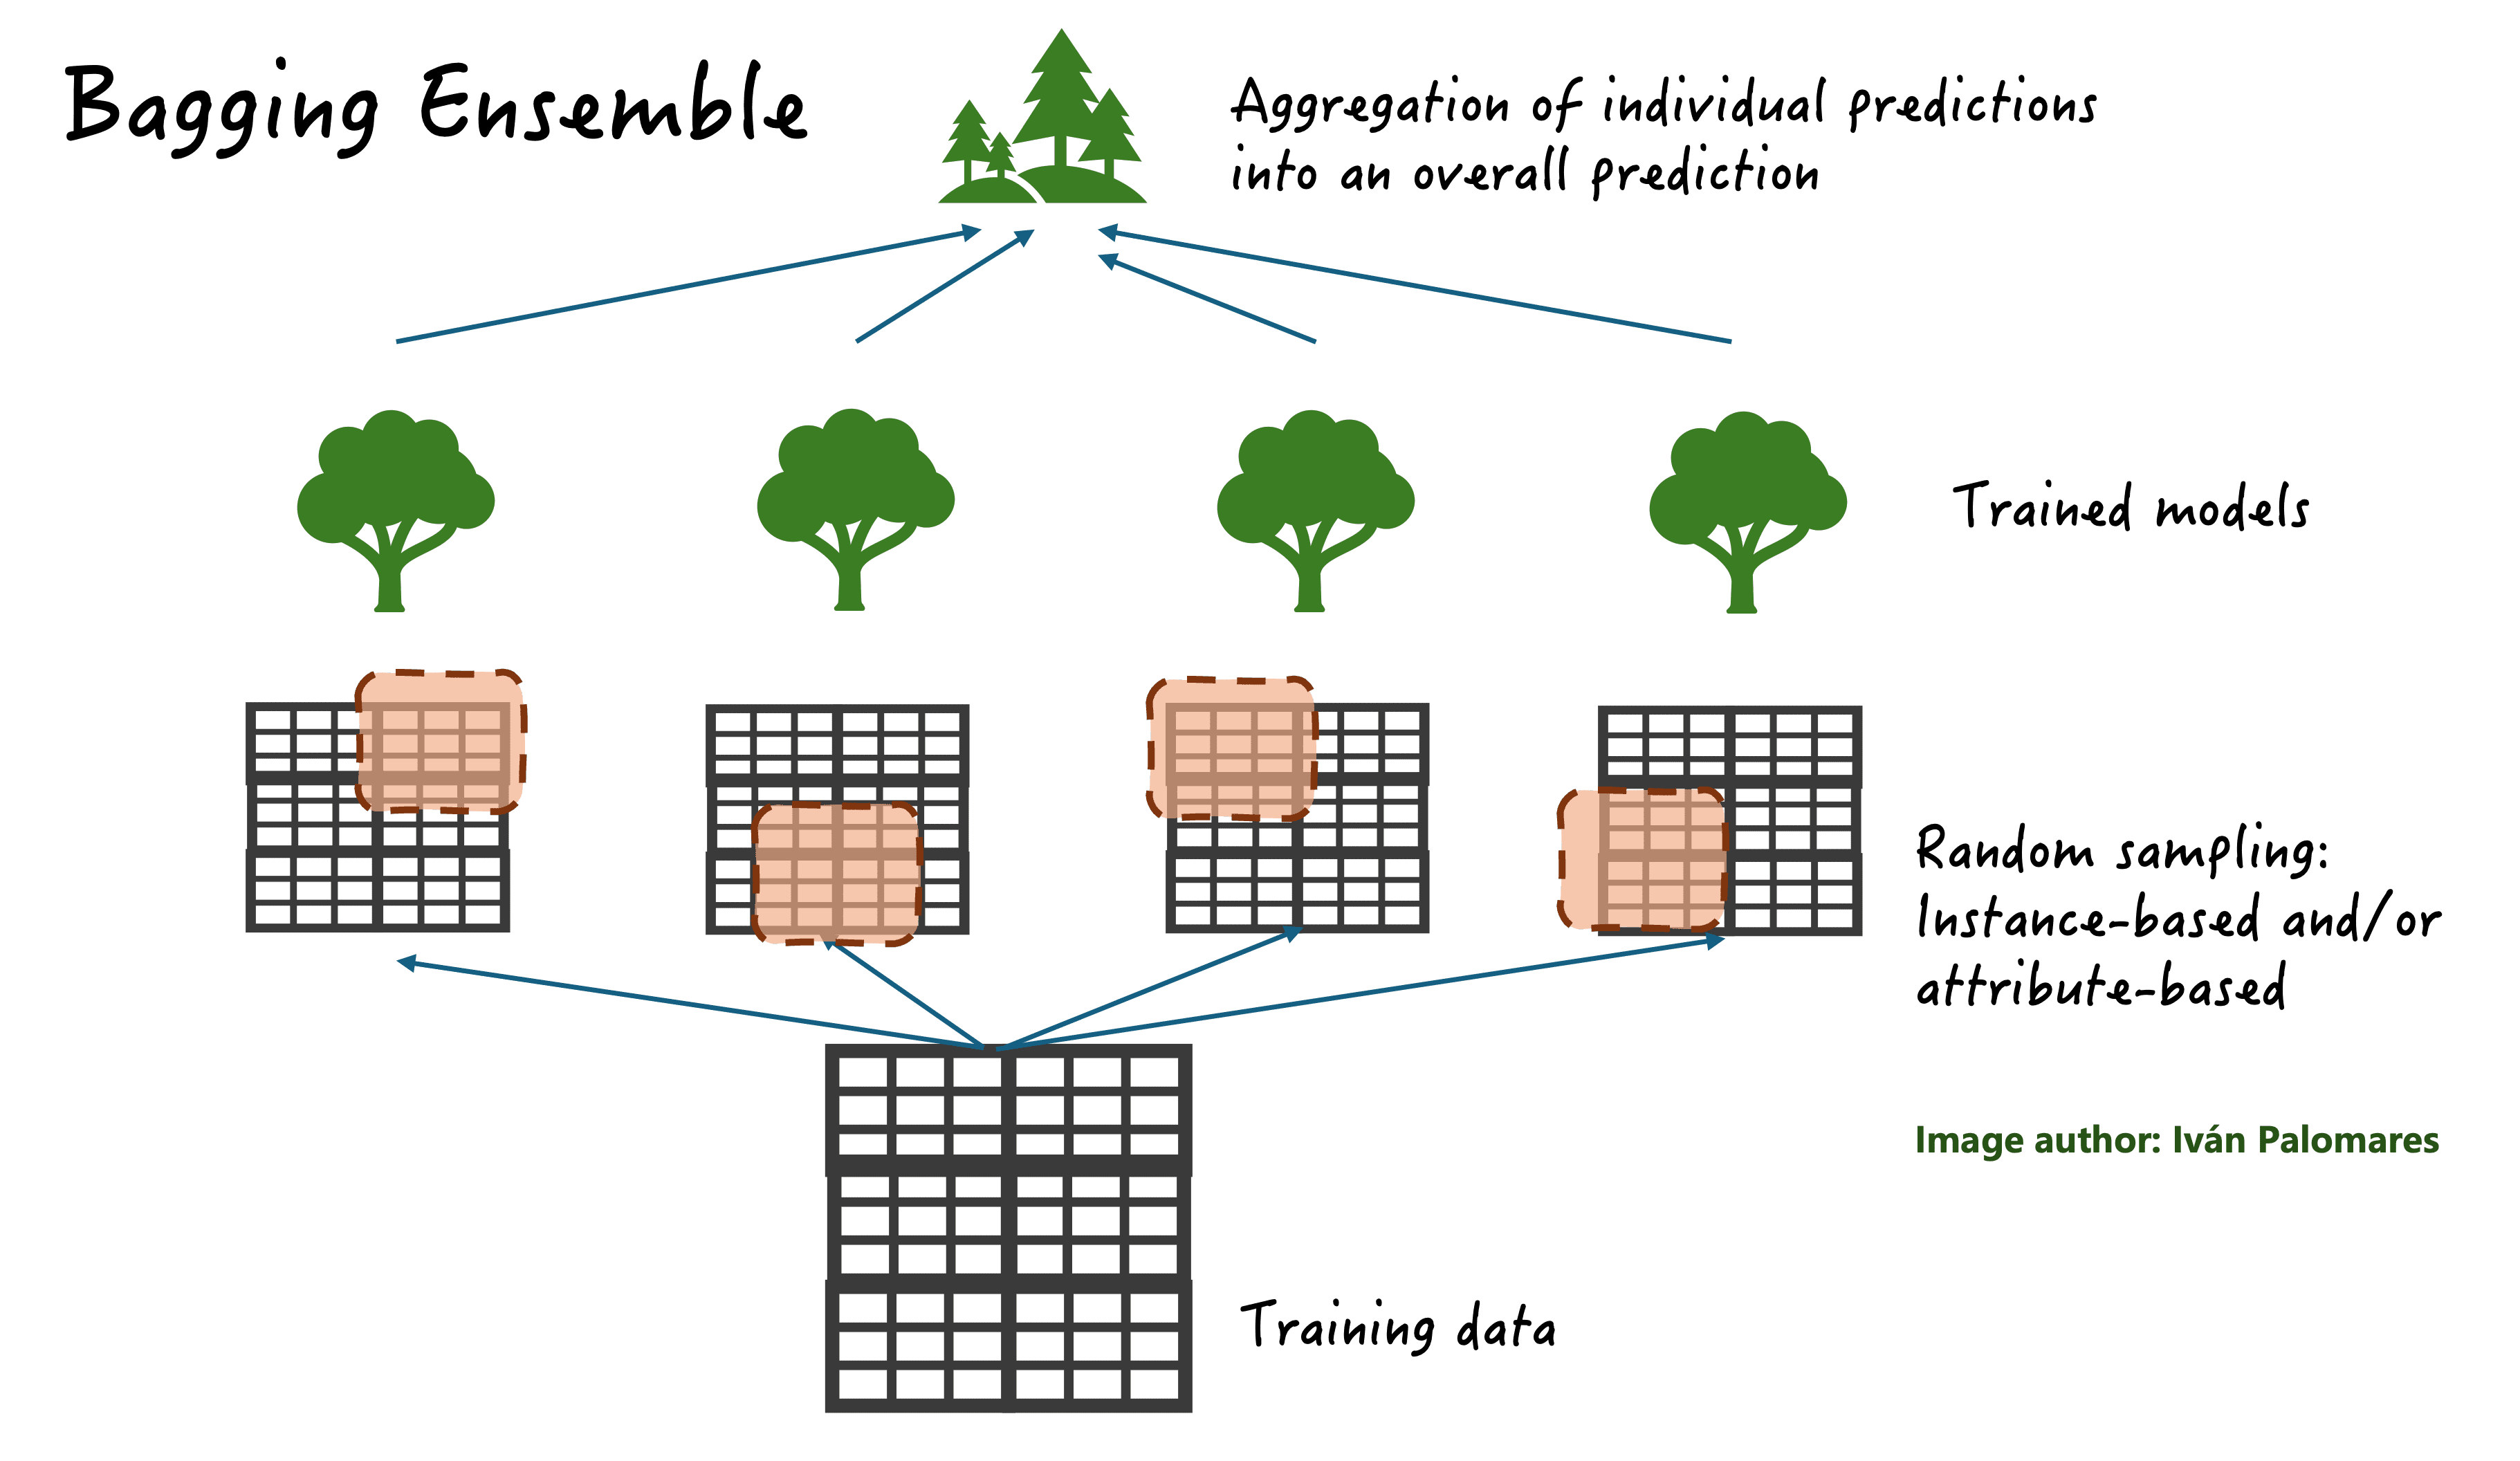

* **개념**: **B**ootstrap **Agg**regat**ing**의 약자로, 원본 데이터셋에서 **복원 추출(Bootstrap)** 을 통해 여러 개의 서로 다른 샘플 데이터셋을 만들고, 각각 동일한 단일 모델로 학습시킨 후 결과를 결합합니다.
* **장점**: 각 모델이 서로 조금씩 다른 무작위 샘플 데이터를 학습하므로 다양성이 부여되고, 과적합(Overfitting)을 효과적으로 방지할 수 있습니다.

In [ ]:
from sklearn.ensemble import BaggingClassifier

# BaggingClassifier 생성
# estimator (구 버전 scikit-learn에서는 base_estimator 사용)
ba_clf = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100, random_state=100)

# 모델 학습 및 예측
ba_clf.fit(X_tr, y_tr)
y_pred_ba = ba_clf.predict(X_te)
print("Bagging 예측 결과 (상위 5개):", y_pred_ba[:5])

### 3-3. Boosting (부스팅)
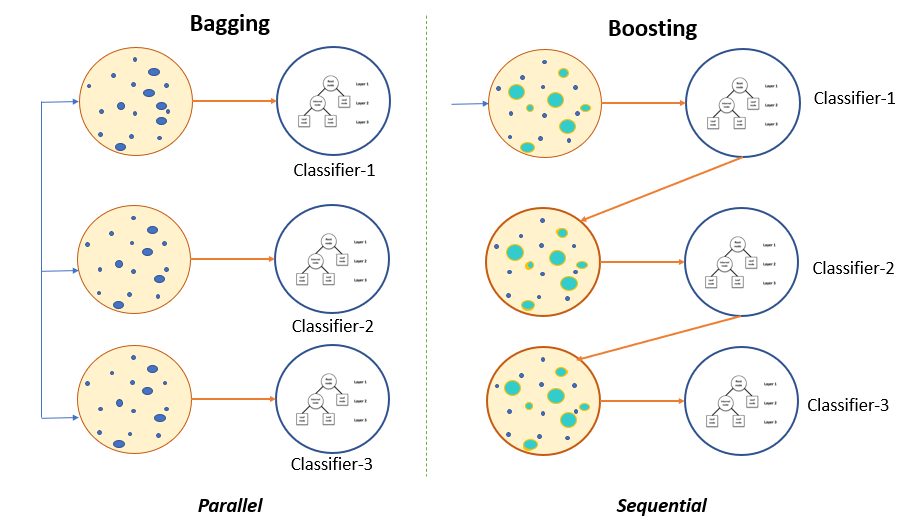

* **개념**: 여러 개의 약한 모델(Weak Learner)을 순차적으로 연결 및 수정하여 하나의 강한 모델(Strong Learner)을 만드는 방식입니다.
* **특징**: 독립적으로 모델을 만들어 합치는 것이 아니라, 앞선 모델이 오분류/오차를 낸 데이터에 **가중치를 부여**하여 다음 모델이 이를 집중적으로 학습하고 개선하도록 만듭니다.
* **주요 계열**: AdaBoost, Gradient Boosting, XGBoost, LightGBM, CatBoost 등

---

## 4. 의사결정나무의 한계 & 대표적인 앙상블 모델들

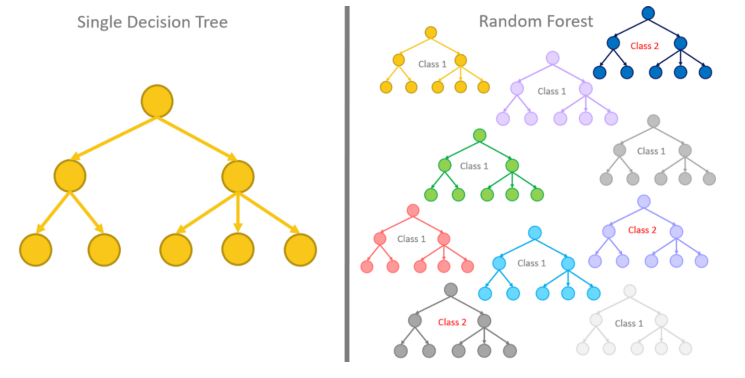

### 4-1. 단일 의사결정나무의 한계
-> 해결책: 랜덤 포레스트 (Random Forest)
* 단일 트리는 과적합될 가능성이 매우 높습니다.
* **랜덤 포레스트 = 의사결정나무 + Bagging**
  * 여러 개의 나무(Decision Tree)를 훈련시켜 거대한 **숲(Forest)** 을 구성하는 알고리즘.
  * **과정**:
    1. 원본 데이터셋에서 Bootstrap으로 N개의 서로 다른 훈련 데이터셋을 생성.
    2. N개의 의사결정나무를 각각 학습.
    3. 학습된 모든 나무들의 예측 결과를 **평균(회귀)** 또는 **다수결 투표(분류)** 방식으로 결합

### 4-2. AdaBoost (Adaptive Boosting)
* 이전 학습 단계를 거치며 잘못 분류된(오분류) 데이터에 가중치를 업데이트하여 다음 모델이 더 잘 예측할 수 있도록 반영합니다.
* 손실함수를 최적화하는 방식으로 가중치를 갱신합니다.
* 이전 단계의 예측 결과를 바탕으로 다음 단계가 진행되므로 **병렬 수행이 불가능**하여 학습 시간이 다소 소요됩니다.

### 4-3. Gradient Boosting (GBM) 및 발전 모델들
* AdaBoost와 유사하지만, 가중치 업데이트 과정에서 **경사하강법(Gradient Descent)** 을 사용합니다.
* 잔차(Residual, 오차)의 기울기를 따라 손실을 줄여나가는 알고리즘으로 연산량이 많이 필요하지만 성능이 매우 뛰어납니다.
* **Gradient Boosting을 현대적으로 응용한 대표 알고리즘들**:
  * **XGBoost**: GBM 대비 빠른 속도와 가속화된 규제(Regularization) 기능 제공
  * **LightGBM (LGBM)**: 리프 중심 분할로 계산 속도와 메모리 사용량을 대폭 절감
  * **CatBoost**: 범주형(Categorical) 변수 처리 성능에 특화

In [ ]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier

# 1. 랜덤 포레스트 (Random Forest)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=100)
rf_clf.fit(X_tr, y_tr)
print("Random Forest 정확도:", rf_clf.score(X_te, y_te))

# 2. AdaBoost
ada_clf = AdaBoostClassifier(n_estimators=100, random_state=100)
ada_clf.fit(X_tr, y_tr)
print("AdaBoost 정확도:", ada_clf.score(X_te, y_te))

# 3. Gradient Boosting
gb_clf = GradientBoostingClassifier(n_estimators=100, random_state=100)
gb_clf.fit(X_tr, y_tr)
print("Gradient Boosting 정확도:", gb_clf.score(X_te, y_te))

---

## 📝 핵심 요약 가이드

1. **의사결정나무**: 단순 직관적인 시각화가 가능하지만 과적합 위험이 있습니다.
2. **회귀나무**: 분할 구역의 오차 제곱합(RSS)을 최소화하도록 Greedy 탐색합니다.
3. **분류나무**: 구역 내의 불순도(Gini, Entropy)를 최소화하여 노드를 순수하게 나눕니다.
4. **Voting**: 각기 다른 종류의 알고리즘 모델들을 모아서 투표/평균합니다.
5. **Bagging (Random Forest)**: 복원추출(Bootstrap)로 다양한 데이터셋을 만들어 독립적으로 여러 나무를 키우고 통합합니다.
6. **Boosting (AdaBoost, GBM, XGBoost)**: 오분류된 데이터나 잔차(오차)에 가중치를 주어 순차적으로 모델을 개선해 나갑니다!